<h1 style="color: green;">Home task : Time Series Forecasting</h1>

In [288]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error



## Load data


In [291]:
df = pd.read_csv("/Users/user/Desktop/Camp2025/lesson_23/data/electricity_consumption_and_production.csv", )
df.head(15)

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30
5,2019-01-01 05:00:00,5525,5385,1395,91,958,1455,1456,0,30
6,2019-01-01 06:00:00,5513,5349,1392,98,938,1451,1440,0,31
7,2019-01-01 07:00:00,5524,5547,1392,93,1187,1446,1394,0,34
8,2019-01-01 08:00:00,5510,5471,1391,51,1325,1357,1303,8,34
9,2019-01-01 09:00:00,5617,5545,1388,15,1398,1328,1319,61,34


In [293]:
target_variable = df["Consumption"]
target_variable.head(15)


0     6352
1     6116
2     5873
3     5682
4     5557
5     5525
6     5513
7     5524
8     5510
9     5617
10    5643
11    5737
12    5776
13    5744
14    5710
Name: Consumption, dtype: int64

## Preprocessing and Cleaning


In [296]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)
target_variable = df["Consumption"]


<Axes: title={'center': 'Electricity Consumption Over Time'}, xlabel='DateTime'>

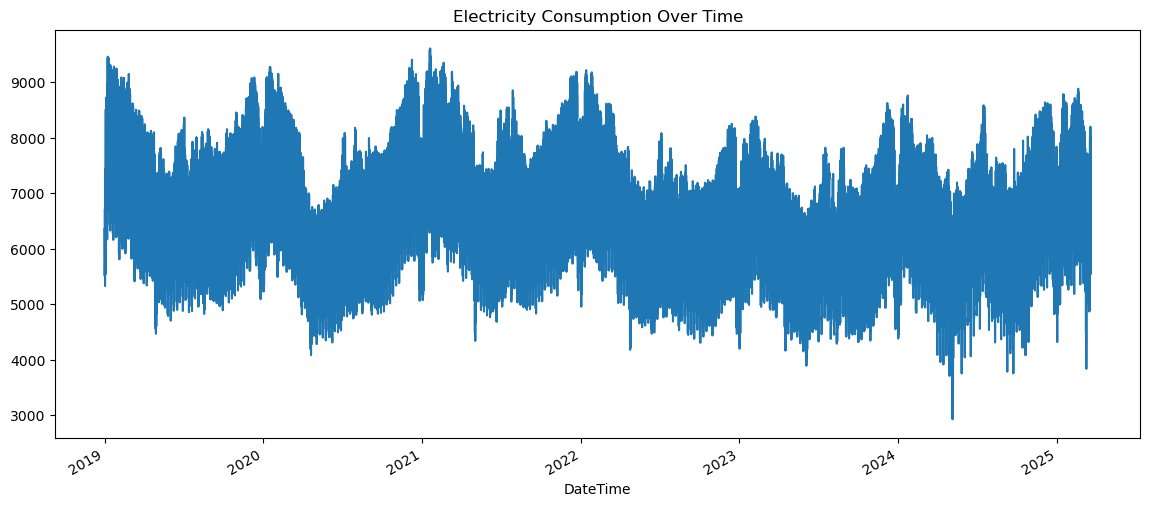

In [298]:

target_variable.plot(
    figsize=(14, 6), 
    title=f"Electricity Consumption Over Time"
)


In [299]:
df = df[~df.index.duplicated(keep='first')]
daily_observations_avg = df["Consumption"].resample("D").mean()
daily_observations_avg


DateTime
2019-01-01    5924.478261
2019-01-02    6322.041667
2019-01-03    7254.083333
2019-01-04    7635.083333
2019-01-05    7423.521739
                 ...     
2025-03-15    5817.956522
2025-03-16    5346.375000
2025-03-17    6603.125000
2025-03-18    6733.250000
2025-03-19    6512.772727
Freq: D, Name: Consumption, Length: 2270, dtype: float64

In [300]:
full_date_range = pd.date_range(start=daily_observations_avg.index.min(), end=daily_observations_avg.index.max(), freq='D')
daily_observations_avg = daily_observations_avg.reindex(full_date_range)
print(f"Total missing values of the target variable: {daily_observations_avg.isna().sum()}")


Total missing values of the target variable: 2


In [301]:
daily_observations_avg = daily_observations_avg.interpolate(method="linear")
print(f"Total missing values of the target variable: {daily_observations_avg.isna().sum()}")


Total missing values of the target variable: 0


In [302]:
daily_observations_avg

2019-01-01    5924.478261
2019-01-02    6322.041667
2019-01-03    7254.083333
2019-01-04    7635.083333
2019-01-05    7423.521739
                 ...     
2025-03-15    5817.956522
2025-03-16    5346.375000
2025-03-17    6603.125000
2025-03-18    6733.250000
2025-03-19    6512.772727
Freq: D, Name: Consumption, Length: 2270, dtype: float64

<Axes: >

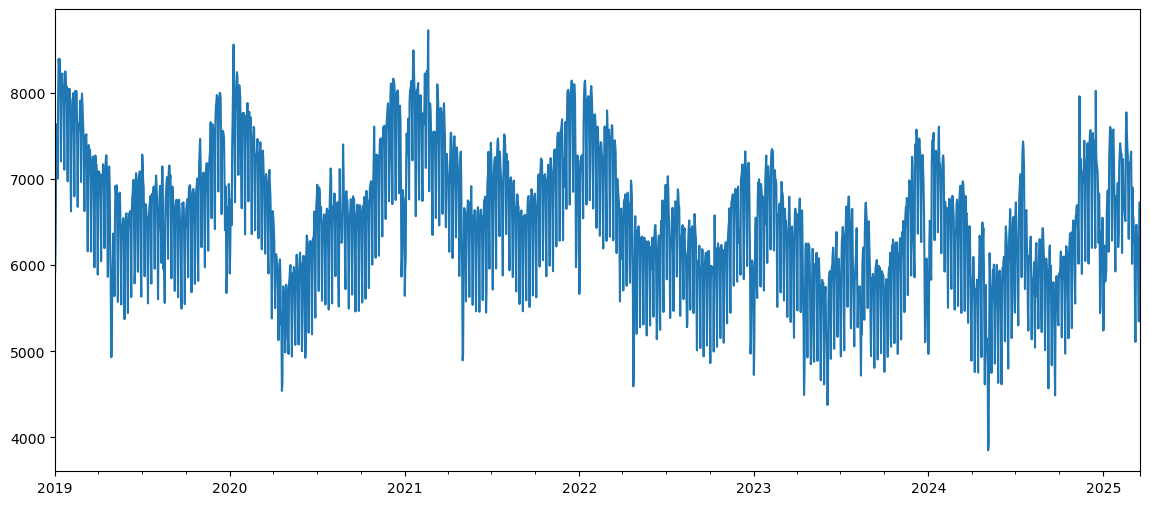

In [304]:
daily_observations_avg.plot(
    figsize=(14, 6)
)

## Seasonal Decomposition

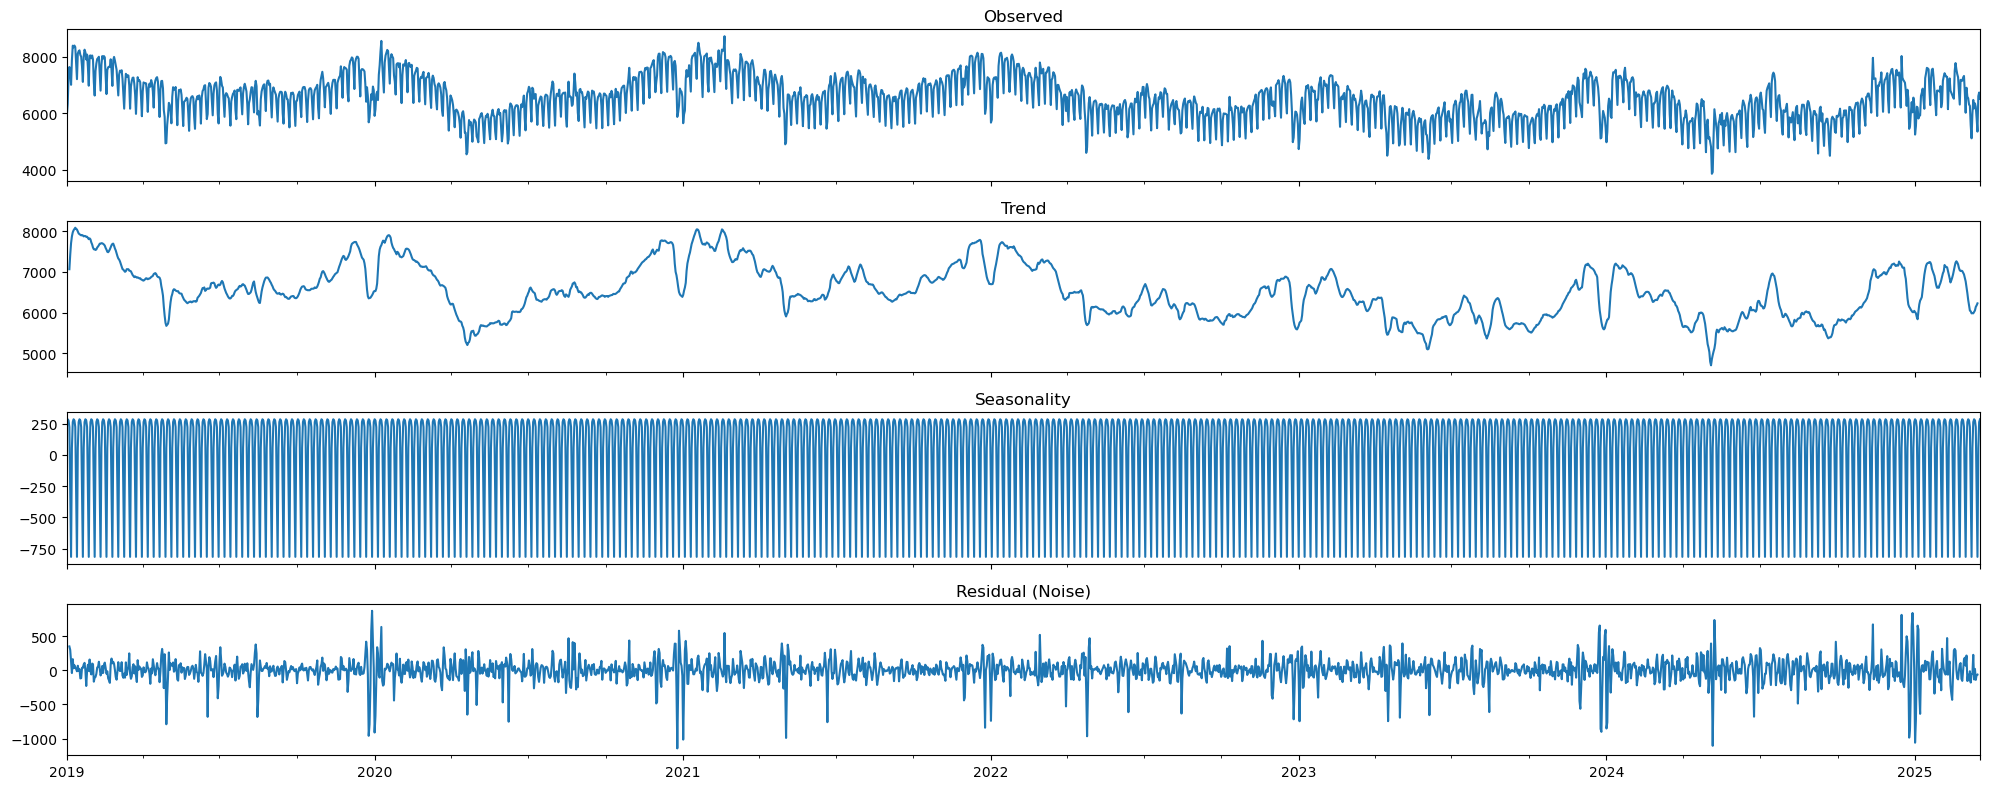

In [310]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_observations_avg, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(20, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)')
plt.tight_layout()

plt.show()

## Weekday consumption

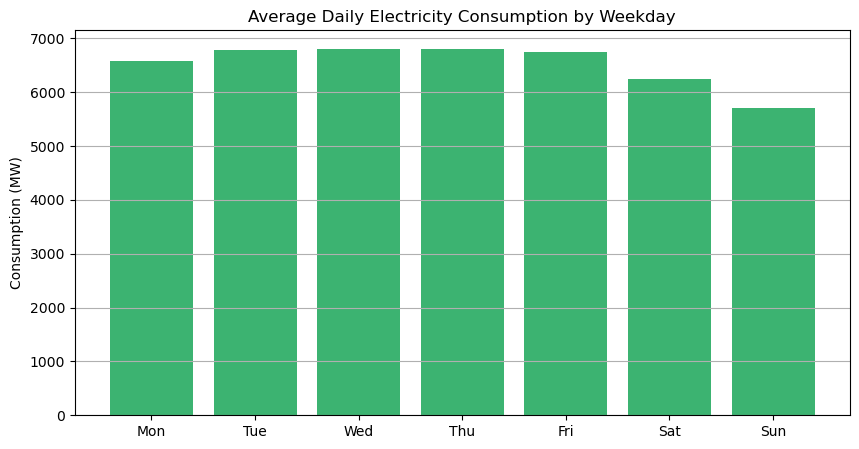

In [313]:
daily_df = pd.DataFrame(daily_observations_avg)
daily_df.columns = ['Consumption']
daily_df['weekday'] = daily_df.index.dayofweek
weekday_avg = daily_df.groupby('weekday')['Consumption'].mean()

plt.figure(figsize=(10, 5))
plt.bar(weekday_avg.index, weekday_avg.values, color='mediumseagreen')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title("Average Daily Electricity Consumption by Weekday")
plt.ylabel("Consumption (MW)")
plt.grid(axis='y')
plt.show()

## Summary Statistics

In [315]:
daily_observations_avg.describe()

count    2270.000000
mean     6526.919607
std       763.583762
min      3851.083333
25%      5993.083333
50%      6542.145833
75%      7045.197917
max      8728.291667
Name: Consumption, dtype: float64

## ADF Stationarity Test

In [317]:
def adf_stationarity_test(time_series: pd.Series):
    adf_result = adfuller(time_series.dropna())
    p_value = adf_result[1]
    print(f"ADF p-value: {p_value:.5f}")
    return p_value < 0.05

is_stationary = adf_stationarity_test(daily_observations_avg)

ADF p-value: 0.01138


## Train-test split

In [319]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
len(daily_observations_avg)


2270

In [320]:
total_day = len(daily_observations_avg)
train_size = int(total_day * 0.8)
test_size = total_day - train_size

train_series = daily_observations_avg[:train_size]
test_series = daily_observations_avg[train_size:]
print(f"Train data: {len(train_series)} days")
print(f"Test data: {len(test_series)} days")

Train data: 1816 days
Test data: 454 days


In [321]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import time

# === Utils ===
def calculate_metrics(test_series: pd.Series, forecast_series: pd.Series):
    """
    Calculate metrics for the forecasted values
    
    Args:
        test_series (pd.Series): Time Series for evaluation
        forecasted_series (pd.Series): Forecasted values

    Returns:
        - mape: Mean Absolute Percentage Error between test vs forecast
        - mae: Mean Absolute Error between test vs forecast 
        - mse: Mean Squared Error between test vs forecast 
    """
    mape = mean_absolute_percentage_error(test_series, forecast_series)
    mae = mean_absolute_error(test_series, forecast_series)
    mse = mean_squared_error(test_series, forecast_series)

    return mape, mae, mse

In [322]:
def visualize_forecast(train, test, forecast, title):
    mape, mae, mse = calculate_metrics(test, forecast)

    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train.values, label='Train')
    plt.plot(test.index, test.values, label='Test (Actual)', color='orange')
    plt.plot(forecast.index, forecast.values, label='Forecast', color='green', linestyle='--')
    
    plt.title(title, fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Consumption')
    plt.legend()
    plt.grid(True)
    
    metrics_text = f"MAPE: {mape:.2f}%\nMAE: {mae:.2f}\nRMSE: {mse:.2f}"
    plt.text(0.98, 0.98, metrics_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.show()


## Train/Test Split

In [324]:
train_size = int(len(daily_observations_avg) * 0.8)
train_data = daily_observations_avg[:train_size]
test_data = daily_observations_avg[train_size:]

len(train_series), len(test_series)

(1816, 454)

## SARIMAX

In [326]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [328]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import statsmodels.api as sm
import time

start_time = time.time()

model_auto = auto_arima(
    train_data,
    seasonal=True,
    m=7,
    start_p=0,
    start_q=0,
    max_p=2,
    max_q=2,
    d=None,
    D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

best_order = model_auto.order
best_seasonal_order = model_auto.seasonal_order

model_sarimax = sm.tsa.SARIMAX(train_data, order=best_order, seasonal_order=best_seasonal_order)
results_sarimax = model_sarimax.fit(disp=False)

training_time = time.time() - start_time
print(f"SARIMAX training time: {training_time:.2f} seconds")
print(f"Best SARIMA parameters: {best_order}, {best_seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[7] intercept   : AIC=26611.540, Time=2.17 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=26763.364, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=24763.201, Time=1.22 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=25399.798, Time=0.90 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=26761.378, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[7] intercept   : AIC=25085.646, Time=0.13 sec
 ARIMA(1,0,0)(2,1,0)[7] intercept   : AIC=24615.346, Time=2.78 sec
 ARIMA(1,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=4.32 sec
 ARIMA(1,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=1.93 sec
 ARIMA(0,0,0)(2,1,0)[7] intercept   : AIC=26621.596, Time=2.29 sec
 ARIMA(2,0,0)(2,1,0)[7] intercept   : AIC=24604.985, Time=3.63 sec
 ARIMA(2,0,0)(1,1,0)[7] intercept   : AIC=24744.220, Time=1.22 sec
 ARIMA(2,0,0)(2,1,1)[7] intercept   : AIC=inf, Time=6.30 sec
 ARIMA(2,0,0)(1,1,1)[7] intercept   : AIC=inf, Time=2.28 sec
 ARIMA(2,0,1)(2,1,0)[7] intercept   : AIC=2

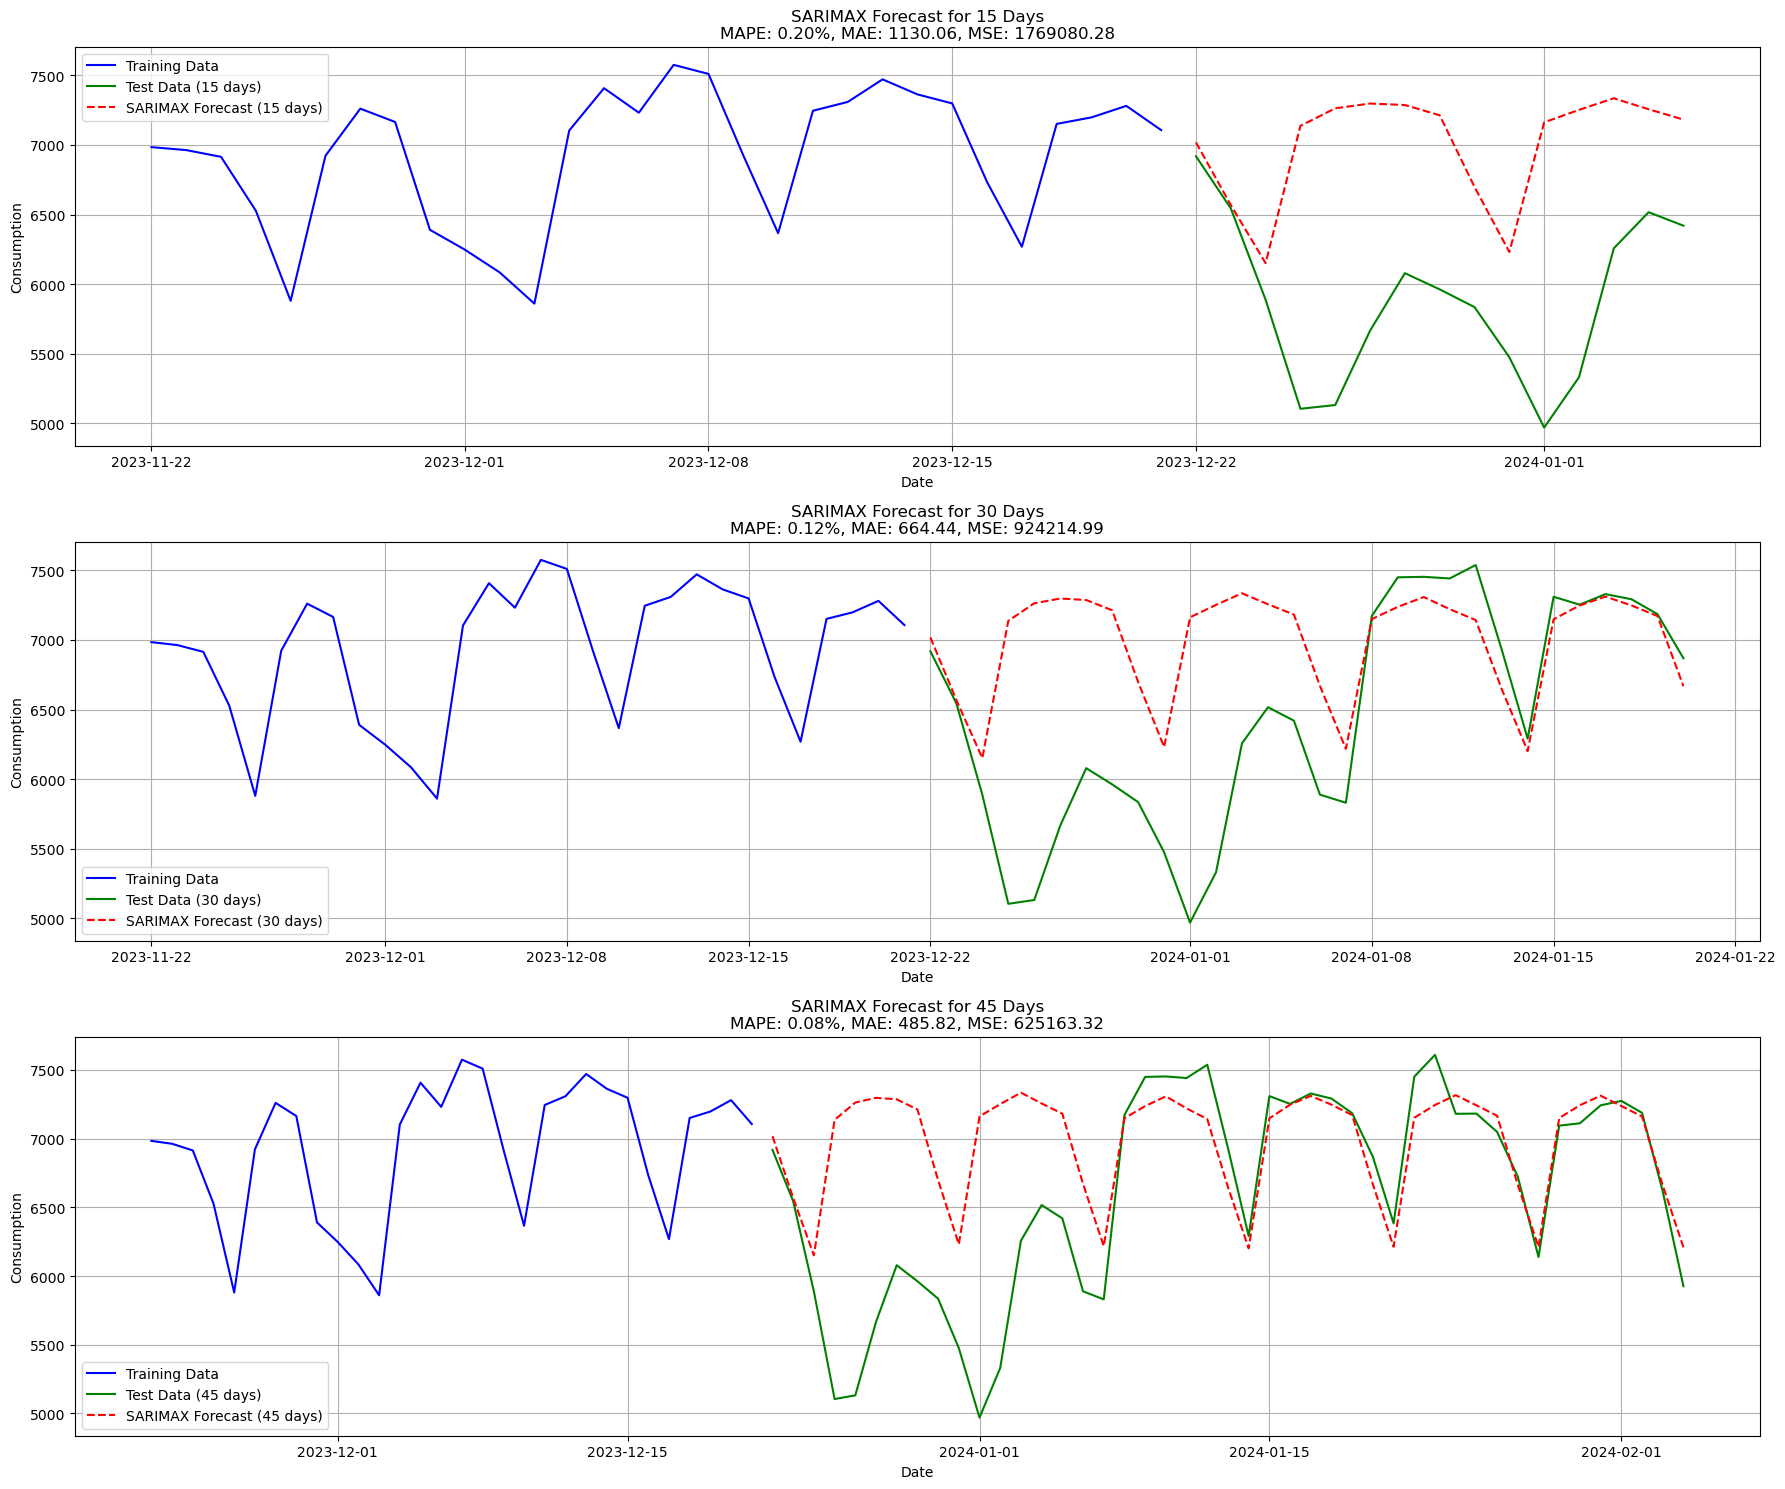

In [329]:
fig, axs = plt.subplots(3, 1, figsize=(18, 15))

for i, days in enumerate([15, 30, 45]):
    axs[i].plot(train_data.iloc[-30:], label='Training Data', color='blue')
    axs[i].plot(test_data[:days], label=f'Test Data ({days} days)', color='green')
    axs[i].plot(forecasts_sarimax[days], label=f'SARIMAX Forecast ({days} days)', color='red', linestyle='--')

    axs[i].set_title(
        f'SARIMAX Forecast for {days} Days\n'
        f'MAPE: {metrics_sarimax[days]["MAPE"]:.2f}%, '
        f'MAE: {metrics_sarimax[days]["MAE"]:.2f}, '
        f'MSE: {metrics_sarimax[days]["MSE"]:.2f}'
    )
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Consumption')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


## Prophet

In [333]:
from prophet import Prophet
import matplotlib.pyplot as plt

train_df_prophet = pd.DataFrame({
    'ds': train_series.index,
    'y': train_series.values
})

model = Prophet()
model.fit(train_df_prophet)

max_horizon = 45
future_df = model.make_future_dataframe(periods=max_horizon, include_history=False, freq='D')
forecast = model.predict(future_df)
forecast_series = forecast.set_index("ds")["yhat"]

forecasts_prophet = {}
metrics_prophet = {}
forecast_periods = [15, 30, 45]

for horizon in forecast_periods:
    forecast_slice = forecast_series.iloc[:horizon]
    forecast_slice.index = test_series.index[:horizon]
    forecasts_prophet[horizon] = forecast_slice
    y_true = test_series[:horizon]
    mape, mae, mse = calculate_metrics(y_true, forecast_slice)
    metrics_prophet[horizon] = {'MAPE': mape, 'MAE': mae, 'MSE': mse}


20:14:28 - cmdstanpy - INFO - Chain [1] start processing
20:14:28 - cmdstanpy - INFO - Chain [1] done processing


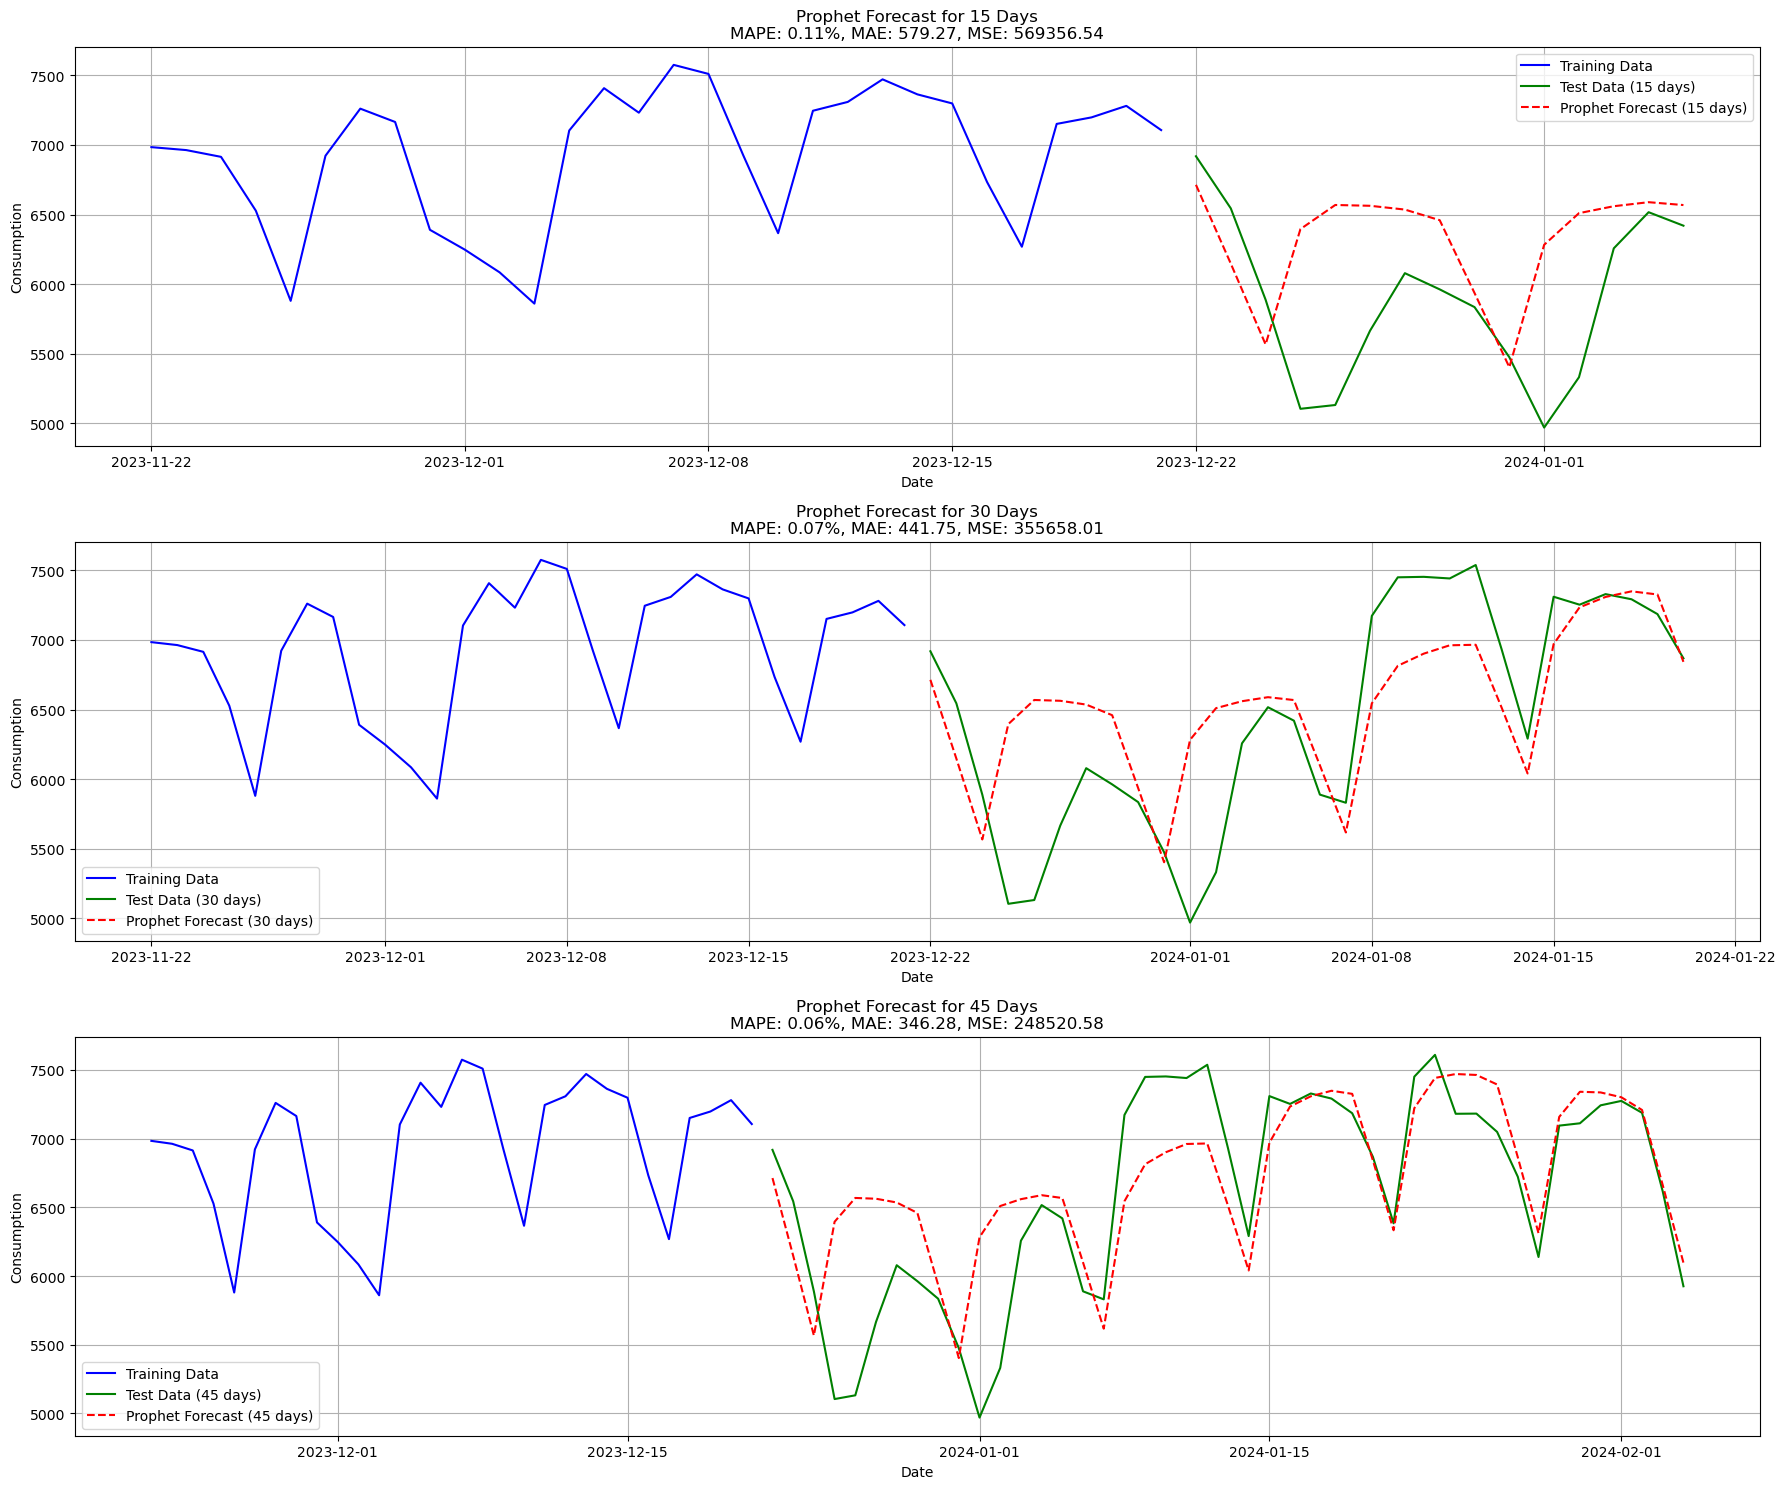

In [335]:
fig, axs = plt.subplots(3, 1, figsize=(18, 15))
for i, horizon in enumerate(forecast_periods):
    axs[i].plot(train_series.iloc[-30:], label='Training Data', color='blue')
    axs[i].plot(test_series[:horizon], label=f'Test Data ({horizon} days)', color='green')
    axs[i].plot(forecasts_prophet[horizon], label=f'Prophet Forecast ({horizon} days)', color='red', linestyle='--')

    axs[i].set_title(
        f'Prophet Forecast for {horizon} Days\n'
        f'MAPE: {metrics_prophet[horizon]["MAPE"]:.2f}%, '
        f'MAE: {metrics_prophet[horizon]["MAE"]:.2f}, '
        f'MSE: {metrics_prophet[horizon]["MSE"]:.2f}'
    )
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Consumption')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

## Time-lagged regression model


In [344]:
from xgboost import XGBRegressor

In [345]:
def create_lag_features(series: pd.Series, lags=14):
    df = pd.DataFrame(series)
    df.columns = ['target']
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df['target'].shift(i)
    df['month'] = df.index.month
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    return df.dropna()

In [346]:
from xgboost import XGBRegressor


In [347]:
lags = 14
lagged_df = create_lag_features(train_series, lags=lags)
X_train = lagged_df.drop(columns=["target"])
y_train = lagged_df["target"]

In [348]:
lags = 14
lagged_df = create_lag_features(train_series, lags=lags)

X_train = lagged_df.drop(columns=["target"])
y_train = lagged_df["target"]


In [349]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [350]:
def recursive_forecast(model, last_values, lags, horizon):
    predictions = []
    current_input = last_values.iloc[-1:].copy()
    for i in range(horizon):
        next_pred = model.predict(current_input.drop('target', axis=1))[0]
        predictions.append(next_pred)
        new_row = current_input.copy()
        new_date = current_input.index[0] + pd.Timedelta(days=1)
        new_row.index = [new_date]
        for j in range(lags, 1, -1):
            new_row[f'lag_{j}'] = current_input[f'lag_{j-1}'].values[0]
        new_row['lag_1'] = next_pred
        new_row['month'] = new_date.month
        new_row['dayofweek'] = new_date.dayofweek
        new_row['dayofyear'] = new_date.dayofyear
        current_input = new_row
    return predictions

forecasts_lagged = {}
metrics_lagged = {}
for days in forecast_periods:
    last_known = lagged_df.iloc[[-1]].copy()
    preds = recursive_forecast(model, last_known, lags, days)
    forecast_index = test_series.index[:days]
    forecast_series = pd.Series(preds, index=forecast_index)
    forecasts_lagged[days] = forecast_series
    y_true = test_series.iloc[:days]
    mape, mae, mse = calculate_metrics(y_true, forecast_series)
    metrics_lagged[days] = {'MAPE': mape, 'MAE': mae, 'MSE': mse}


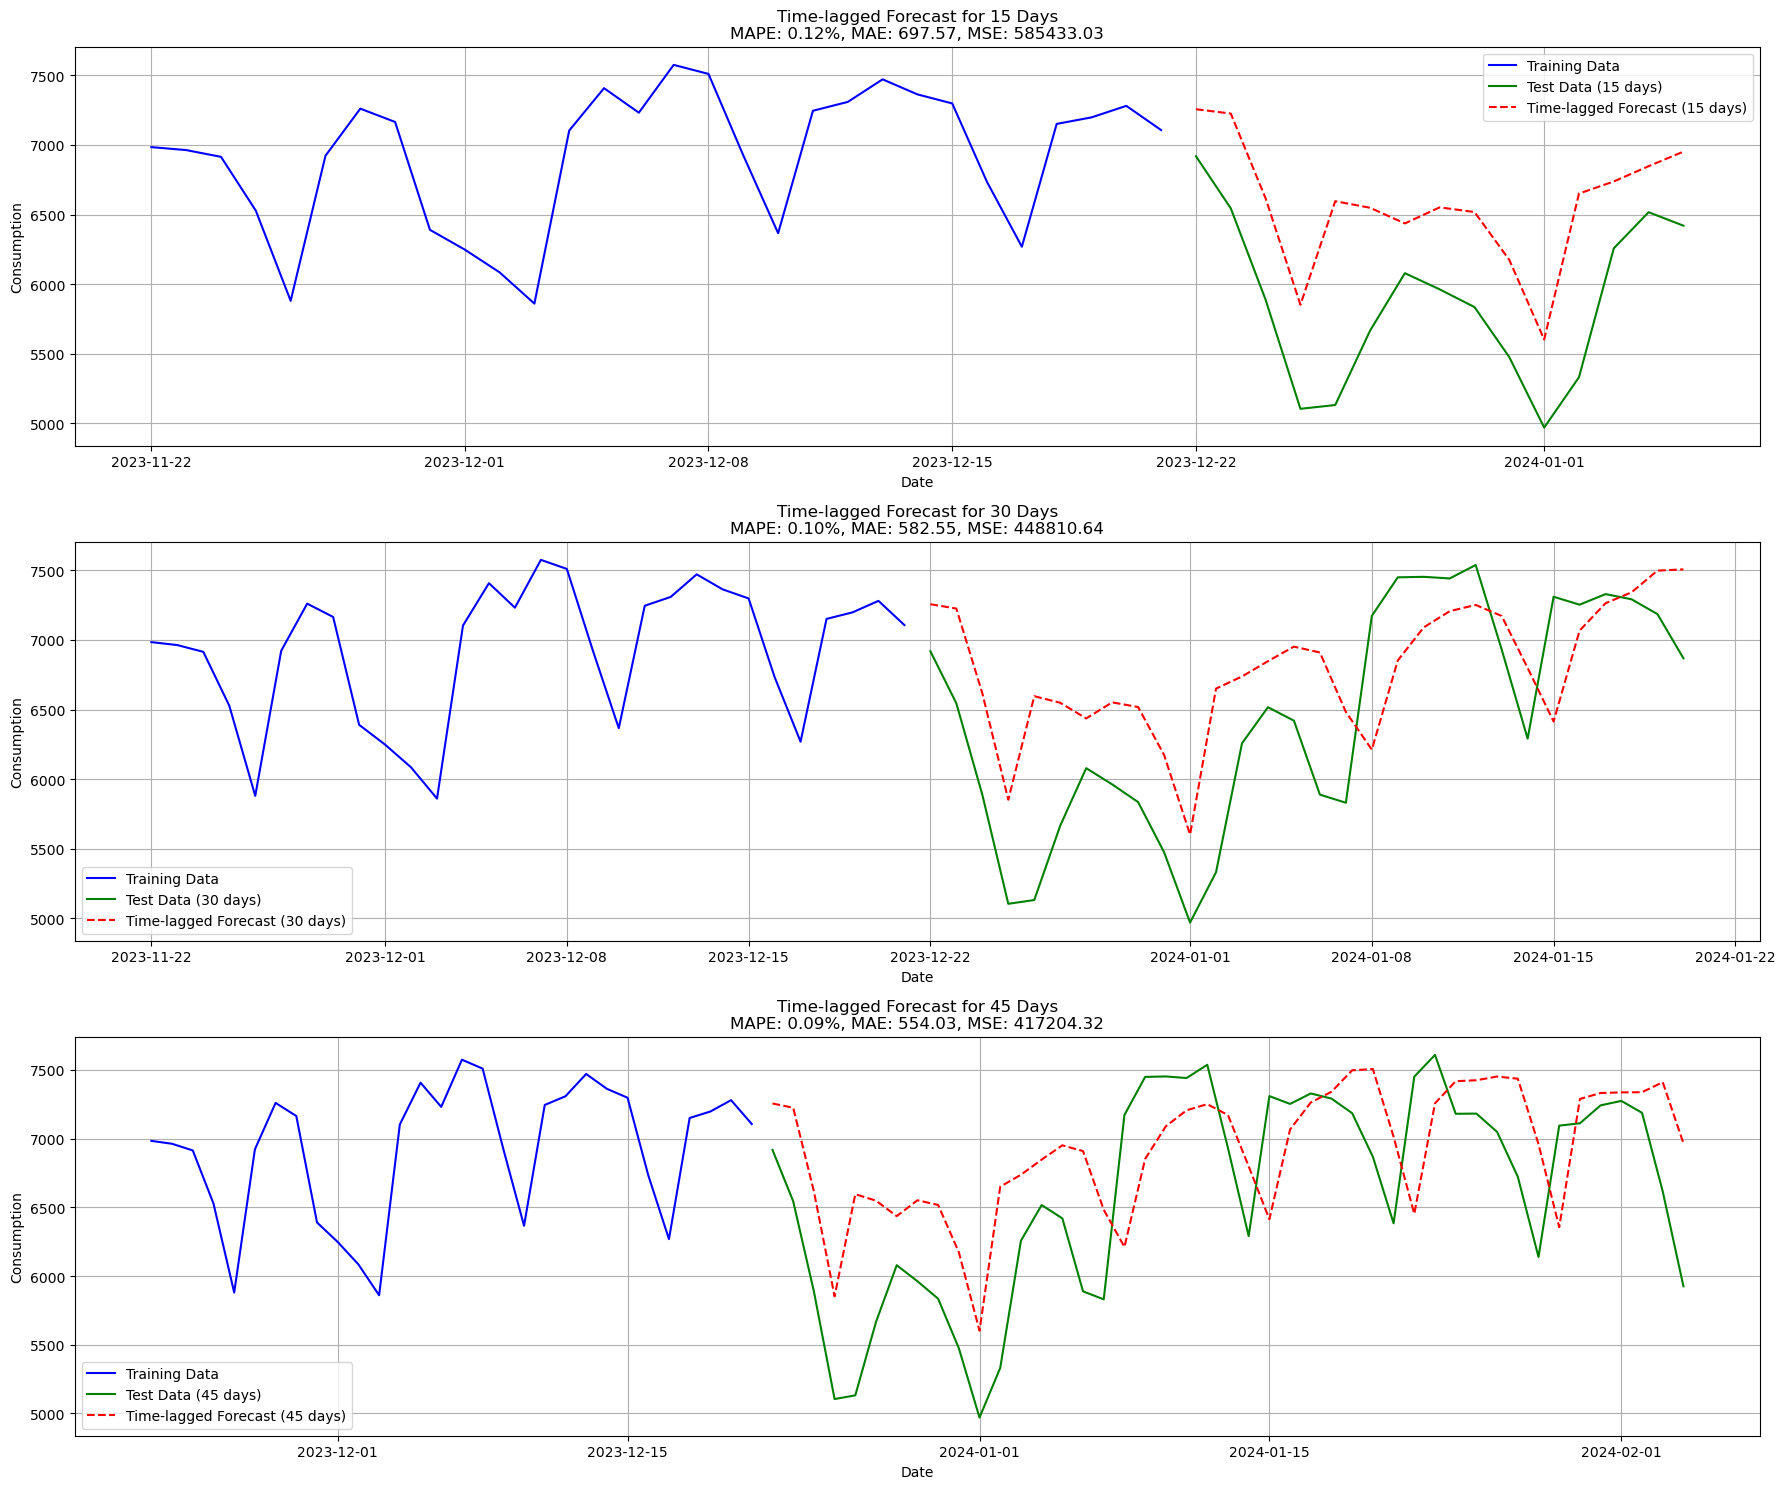

In [351]:
fig, axs = plt.subplots(3, 1, figsize=(18, 15))
for i, days in enumerate(forecast_periods):
    axs[i].plot(train_series.iloc[-30:], label='Training Data', color='blue')
    axs[i].plot(test_series[:days], label=f'Test Data ({days} days)', color='green')
    axs[i].plot(forecasts_lagged[days], label=f'Time-lagged Forecast ({days} days)', color='red', linestyle='--')

    axs[i].set_title(
        f'Time-lagged Forecast for {days} Days\n'
        f'MAPE: {metrics_lagged[days]["MAPE"]:.2f}%, '
        f'MAE: {metrics_lagged[days]["MAE"]:.2f}, '
        f'MSE: {metrics_lagged[days]["MSE"]:.2f}'
    )
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Consumption')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [352]:
from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame


In [353]:
import pandas as pd

metrics_xgb = metrics_lagged

results_df = pd.DataFrame({
    'SARIMAX': metrics_sarimax,
    'Prophet': metrics_prophet,
    'XGBoost': metrics_xgb,
})

results_df = results_df.applymap(
    lambda x: f"MAPE: {x['MAPE']:.2f}%, MAE: {x['MAE']:.1f}, MSE: {x['MSE']:.1f}"
    if isinstance(x, dict) else x
)

display(results_df)


,SARIMAX,Prophet,XGBoost
15,"MAPE: 0.20%, MAE: 1130.1, MSE: 1769080.3","MAPE: 0.11%, MAE: 579.3, MSE: 569356.5","MAPE: 0.12%, MAE: 697.6, MSE: 585433.0"
30,"MAPE: 0.12%, MAE: 664.4, MSE: 924215.0","MAPE: 0.07%, MAE: 441.8, MSE: 355658.0","MAPE: 0.10%, MAE: 582.6, MSE: 448810.6"
45,"MAPE: 0.08%, MAE: 485.8, MSE: 625163.3","MAPE: 0.06%, MAE: 346.3, MSE: 248520.6","MAPE: 0.09%, MAE: 554.0, MSE: 417204.3"


# Conclusion: Model Selection and Justification


### **SARIMAX**

**Pros**
* Built-in time series support with seasonal structure.

* Good accuracy over longer horizons (low MAPE at 45 days).

**Cons**
* Slower training and inference time.

* Less flexible to sudden changes or nonlinear trends.

* Parameter tuning can be complex.

### **PROPHET**

**Pros**

* Very intuitive and quick to set up.

* Strong performance across all horizons.

* Automatically handles trends, holidays, and seasonality.

* Easiest to interpret.

**Cons**

* Assumes additive models by default.

* May not capture complex patterns as well as machine learning models.



### **Time-lagged Regression model**

**Pros**

* Highly flexible and powerful with engineered lag features.

* Accurate for short and medium-term forecasts.

* Captures nonlinear dependencies.

**Cons**
* Requires careful feature engineering (lags, time features).

* Doesn’t model seasonality explicitly.

* Slightly worse than Prophet in all metrics, but still competitive.

### **Best Model**


#### *Prophet outperformed other models in all tested horizons across all metrics (MAPE, MAE, MSE), and is also faster to train and deploy. It is therefore selected as the most optimal model in terms of accuracy vs time efficiency.*



<h1 style="color: red;">Why Chronos-Bolt Was Not Used</h1>

#### Despite multiple attempts, the Chronos-Bolt model could not be successfully integrated into this forecasting pipeline. Below is a detailed breakdown of the issues encountered and the steps taken to resolve them. ####



* When using the Chronos Bolt code from the lecture as a template, I encountered a problem with the model loading endlessly.

* Attempt to fix with dependency downgrading/upgrading
Adjusted transformers, torch, chronos, huggingface_hub, and related packages.
Resulted in version conflicts and full failure of other models (e.g., Prophet, XGBoost) due to broken environments.
Also attempted use of torch.float32 and float16 instead of bfloat16 — without success.
* Instability across multiple platforms (macOS with Intel i7).

*  Final Attempt via AutoGluon (Chronos integration).This approach also failed during model loading (ChronosModel.load()), likely due to incomplete Chronos integration with AutoGluon, or missing model weights in the environment.